In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

df = pd.read_csv(DATA_DIR / "iris_random_forest.csv")
display(df.head())
display(df["Species"].value_counts().rename_axis("Species").reset_index(name="count"))

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


,Species,count
0,Iris-setosa,50
1,Iris-versicolor,50
2,Iris-virginica,50


Accuracy: 0.895
OOB score: 0.955
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.80      0.92      0.86        13
 Iris-virginica       0.91      0.77      0.83        13

       accuracy                           0.89        38
      macro avg       0.90      0.90      0.90        38
   weighted avg       0.90      0.89      0.89        38



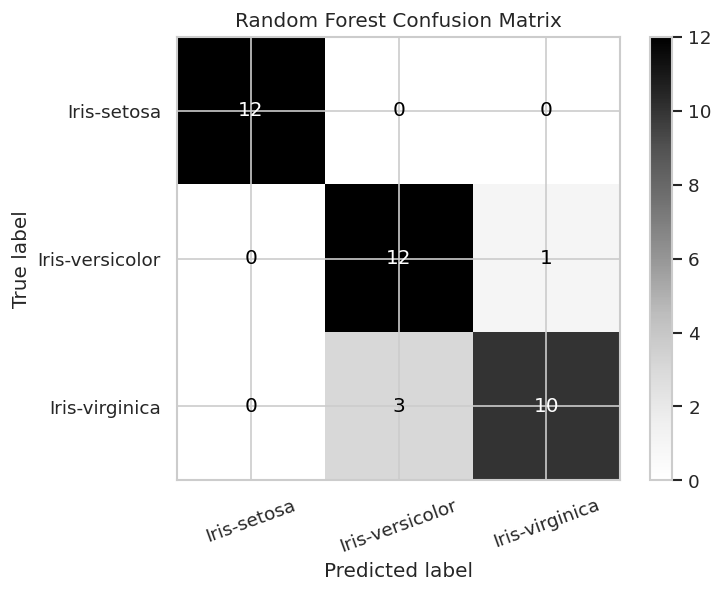

In [3]:
X = df.drop(columns=["Id", "Species"])
labeler = LabelEncoder()
y = labeler.fit_transform(df["Species"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=RANDOM_STATE,
    oob_score=True,
)
forest.fit(X_train, y_train)
pred = forest.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print(f"OOB score: {forest.oob_score_:.3f}")
print(classification_report(y_test, pred, target_names=labeler.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=labeler.classes_, cmap="Greys")
plt.xticks(rotation=20)
plt.title("Random Forest Confusion Matrix")
plt.show()

,feature,importance
2,PetalLengthCm,0.456218
3,PetalWidthCm,0.407868
0,SepalLengthCm,0.111614
1,SepalWidthCm,0.024300


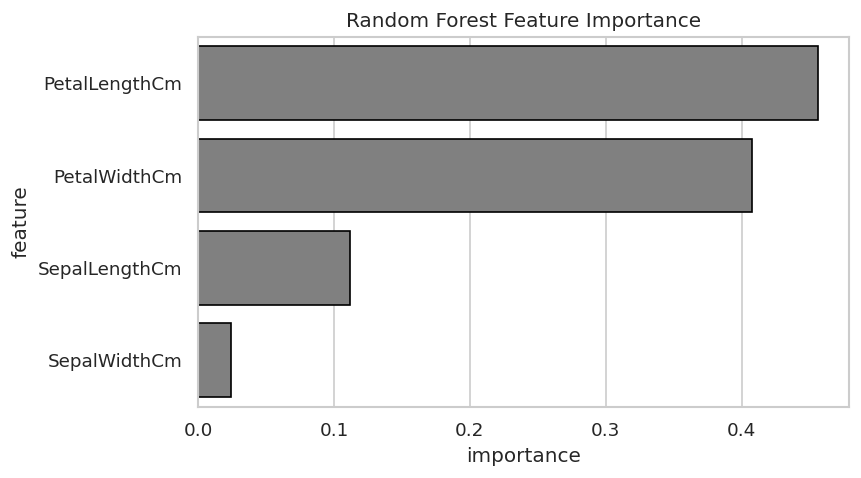

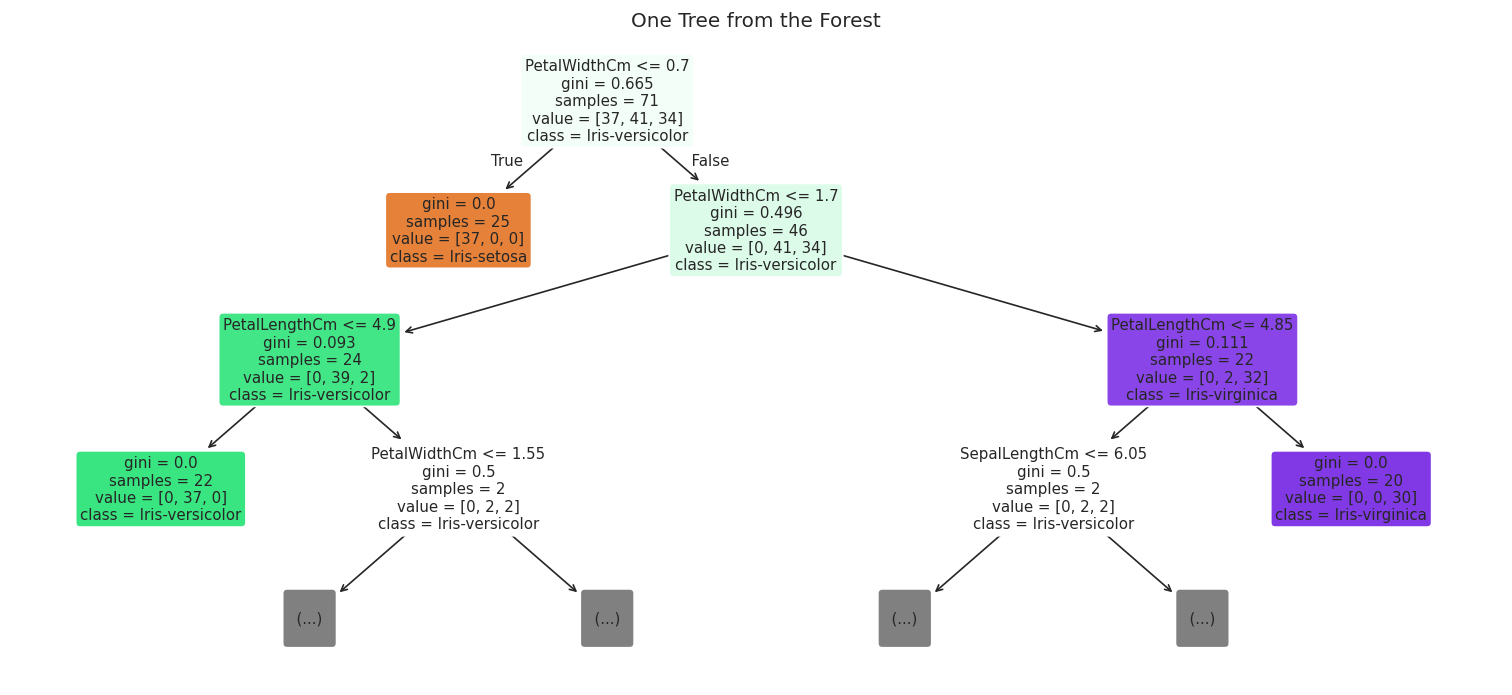

In [4]:
importance = pd.DataFrame(
    {"feature": X.columns, "importance": forest.feature_importances_}
).sort_values("importance", ascending=False)
display(importance)

plt.figure(figsize=(7, 4))
sns.barplot(data=importance, x="importance", y="feature", color="gray", edgecolor="black")
plt.title("Random Forest Feature Importance")
plt.show()

plt.figure(figsize=(16, 7))
plot_tree(
    forest.estimators_[0],
    feature_names=X.columns,
    class_names=labeler.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title("One Tree from the Forest")
plt.show()